# Task 5 – Attention Strategy for Text-to-Image Generation

## Objective

The objective of this task is to improve the quality of text-to-image generation by incorporating an attention mechanism into the image generation model.

The attention mechanism enables the model to focus on the most relevant textual features while generating images, resulting in better semantic alignment between the input text and the generated output.

This task demonstrates the implementation and application of an attention mechanism within the image generation pipeline.

In [1]:
# ==========================================================
# Task 5: Cross Attention GAN
# Install Required Libraries
# ==========================================================

!pip -q install transformers
!pip -q install datasets
!pip -q install accelerate
!pip -q install sentencepiece
!pip -q install timm

In [2]:
# ==========================================================
# Task 5: Cross-Attention GAN
# Import Required Libraries
# ==========================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms

from transformers import CLIPTokenizer, CLIPTextModel

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

print("✅ All libraries imported successfully!")
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

Mounted at /content/drive
✅ All libraries imported successfully!
Device: GPU


Dataset Path: /content/drive/MyDrive/Task1_Dataset/images
Total Images: 30


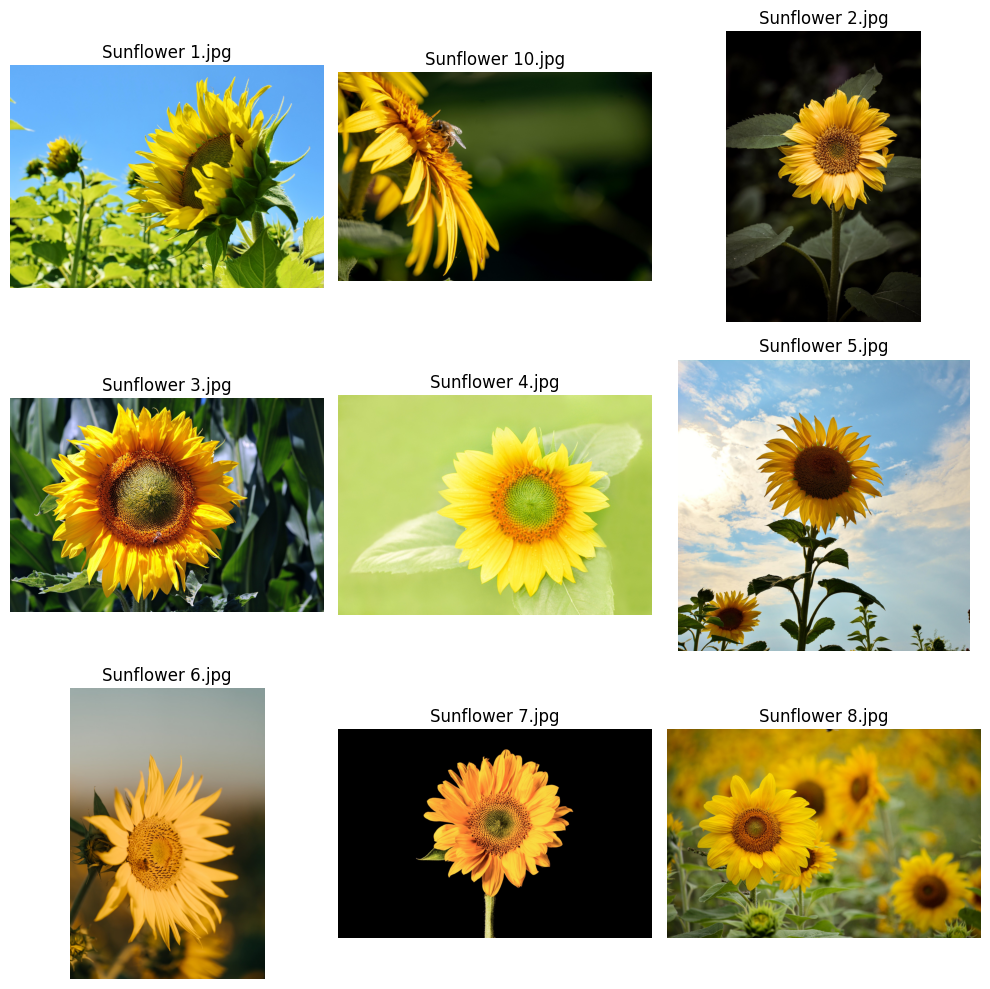

In [3]:
# ==========================================================
# Task 5: Load Flower Dataset
# ==========================================================

# Dataset path
image_dir = "/content/drive/MyDrive/Task1_Dataset/images"

# Get image filenames
image_files = sorted([
    f for f in os.listdir(image_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("Dataset Path:", image_dir)
print("Total Images:", len(image_files))

# Display first 9 images
plt.figure(figsize=(10,10))

for i in range(9):
    img = Image.open(os.path.join(image_dir, image_files[i]))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(image_files[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# ==========================================================
# Task 5: Create Text Prompts and Dataset
# ==========================================================

# Create a text prompt for every flower image
text_prompts = ["A beautiful colorful flower" for _ in image_files]

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Custom Dataset
class FlowerDataset(Dataset):
    def __init__(self, image_dir, image_files, prompts, transform=None):
        self.image_dir = image_dir
        self.image_files = image_files
        self.prompts = prompts
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        prompt = self.prompts[idx]

        return image, prompt

# Create Dataset
dataset = FlowerDataset(
    image_dir=image_dir,
    image_files=image_files,
    prompts=text_prompts,
    transform=transform
)

print("Dataset Size:", len(dataset))
print("Example Prompt:", dataset[0][1])
print("Image Shape:", dataset[0][0].shape)

Dataset Size: 30
Example Prompt: A beautiful colorful flower
Image Shape: torch.Size([3, 256, 256])


In [5]:
# ==========================================================
# Task 5: Load CLIP Text Encoder
# ==========================================================

# Load tokenizer
tokenizer = CLIPTokenizer.from_pretrained(
    "openai/clip-vit-base-patch32"
)

# Load text encoder
text_encoder = CLIPTextModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

print("✅ CLIP Tokenizer Loaded")
print("✅ CLIP Text Encoder Loaded")

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.l

✅ CLIP Tokenizer Loaded
✅ CLIP Text Encoder Loaded


In [6]:
# ==========================================================
# Task 5: Generate Text Embeddings
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
text_encoder = text_encoder.to(device)

sample_prompt = "A beautiful colorful flower"

# Tokenize
inputs = tokenizer(
    sample_prompt,
    return_tensors="pt",
    padding=True,
    truncation=True
)

inputs = {k: v.to(device) for k, v in inputs.items()}

# Generate embeddings
with torch.no_grad():
    outputs = text_encoder(**inputs)

text_embeddings = outputs.last_hidden_state

print("Embedding Shape:", text_embeddings.shape)
print("Device:", text_embeddings.device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Embedding Shape: torch.Size([1, 6, 512])
Device: cuda:0


In [7]:
# ==========================================================
# Task 5: Cross-Attention Module
# ==========================================================

import torch.nn as nn

class CrossAttention(nn.Module):
    def __init__(self, image_dim=512, text_dim=512, num_heads=8):
        super().__init__()

        self.cross_attention = nn.MultiheadAttention(
            embed_dim=image_dim,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, image_features, text_features):

        attended_features, attention_weights = self.cross_attention(
            query=image_features,
            key=text_features,
            value=text_features
        )

        return attended_features, attention_weights


print("✅ Cross-Attention Module Created Successfully")

✅ Cross-Attention Module Created Successfully


In [8]:
# ==========================================================
# Task 5: Test Cross-Attention
# ==========================================================

# Create Cross-Attention model
cross_attention = CrossAttention().to(device)

# Dummy image features
image_features = torch.randn(1, 6, 512).to(device)

# Pass through Cross-Attention
attended_features, attention_weights = cross_attention(
    image_features,
    text_embeddings
)

print("Image Feature Shape :", image_features.shape)
print("Text Embedding Shape:", text_embeddings.shape)
print("Output Shape        :", attended_features.shape)
print("Attention Shape     :", attention_weights.shape)

Image Feature Shape : torch.Size([1, 6, 512])
Text Embedding Shape: torch.Size([1, 6, 512])
Output Shape        : torch.Size([1, 6, 512])
Attention Shape     : torch.Size([1, 6, 6])


In [9]:
# ==========================================================
# Task 5: Attention-Enhanced Generator
# ==========================================================

class AttentionGenerator(nn.Module):
    def __init__(self, noise_dim=100, text_dim=512, image_size=64):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(noise_dim + text_dim, 1024),
            nn.ReLU(),

            nn.Linear(1024, 2048),
            nn.ReLU(),

            nn.Linear(2048, 3 * image_size * image_size),
            nn.Tanh()
        )

        self.image_size = image_size

    def forward(self, noise, attended_text):

        # Average attention features
        text_vector = attended_text.mean(dim=1)

        x = torch.cat([noise, text_vector], dim=1)

        output = self.fc(x)

        output = output.view(-1, 3, self.image_size, self.image_size)

        return output

print("✅ Attention Generator Created Successfully")

✅ Attention Generator Created Successfully


Generated Image Shape: torch.Size([1, 3, 64, 64])


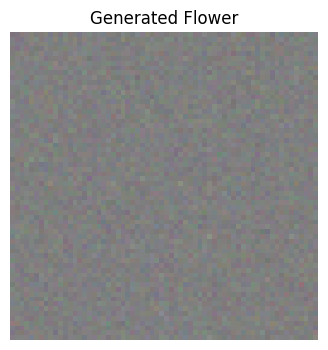

In [10]:
# ==========================================================
# Task 5: Test Attention Generator
# ==========================================================

generator = AttentionGenerator().to(device)

noise = torch.randn(1, 100).to(device)

generated_image = generator(noise, attended_features)

print("Generated Image Shape:", generated_image.shape)

# Display Image
img = generated_image[0].detach().cpu()

# Convert from [-1,1] → [0,1]
img = (img + 1) / 2

plt.figure(figsize=(4,4))
plt.imshow(img.permute(1,2,0))
plt.axis("off")
plt.title("Generated Flower")
plt.show()

In [11]:
import glob
import os

dataset_path = "/content/drive/MyDrive/Task1_Dataset/images"

image_paths = sorted(glob.glob(os.path.join(dataset_path, "*")))

print("Total Images:", len(image_paths))
print(image_paths[:5])  # Show first 5 image paths

Total Images: 30
['/content/drive/MyDrive/Task1_Dataset/images/Sunflower 1.jpg', '/content/drive/MyDrive/Task1_Dataset/images/Sunflower 10.jpg', '/content/drive/MyDrive/Task1_Dataset/images/Sunflower 2.jpg', '/content/drive/MyDrive/Task1_Dataset/images/Sunflower 3.jpg', '/content/drive/MyDrive/Task1_Dataset/images/Sunflower 4.jpg']


In [12]:
# ==========================================================
# Task 5: DataLoader
# ==========================================================

from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class FlowerDataset(torch.utils.data.Dataset):

    def __init__(self, image_paths):
        self.image_paths = image_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = transform(image)

        return image

dataset = FlowerDataset(image_paths)

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True
)

print("Dataset Size:", len(dataset))
print("Batches:", len(dataloader))

Dataset Size: 30
Batches: 8


In [13]:
# ==========================================================
# Task 5: Training Loop
# ==========================================================

import torch.optim as optim

generator = AttentionGenerator().to(device)

optimizer = optim.Adam(generator.parameters(), lr=0.0002)

epochs = 20

loss_function = nn.MSELoss()

attended_features = attended_features.detach()

generator.train()

for epoch in range(epochs):

    epoch_loss = 0

    for images in dataloader:

        images = images.to(device)

        batch_size = images.size(0)

        noise = torch.randn(batch_size, 100).to(device)

        text_features = attended_features.detach().repeat(batch_size, 1, 1)

        generated_images = generator(noise, text_features)

        loss = loss_function(generated_images, images)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

print("✅ Training Completed Successfully!")

Epoch [1/20] Loss: 3.2415
Epoch [2/20] Loss: 2.7198
Epoch [3/20] Loss: 2.7432
Epoch [4/20] Loss: 2.6462
Epoch [5/20] Loss: 2.6589
Epoch [6/20] Loss: 2.8514
Epoch [7/20] Loss: 2.6514
Epoch [8/20] Loss: 2.7086
Epoch [9/20] Loss: 2.8040
Epoch [10/20] Loss: 2.7447
Epoch [11/20] Loss: 2.7302
Epoch [12/20] Loss: 2.6195
Epoch [13/20] Loss: 2.6398
Epoch [14/20] Loss: 2.6290
Epoch [15/20] Loss: 2.7622
Epoch [16/20] Loss: 2.7012
Epoch [17/20] Loss: 2.5984
Epoch [18/20] Loss: 2.7335
Epoch [19/20] Loss: 2.6657
Epoch [20/20] Loss: 2.6728
✅ Training Completed Successfully!


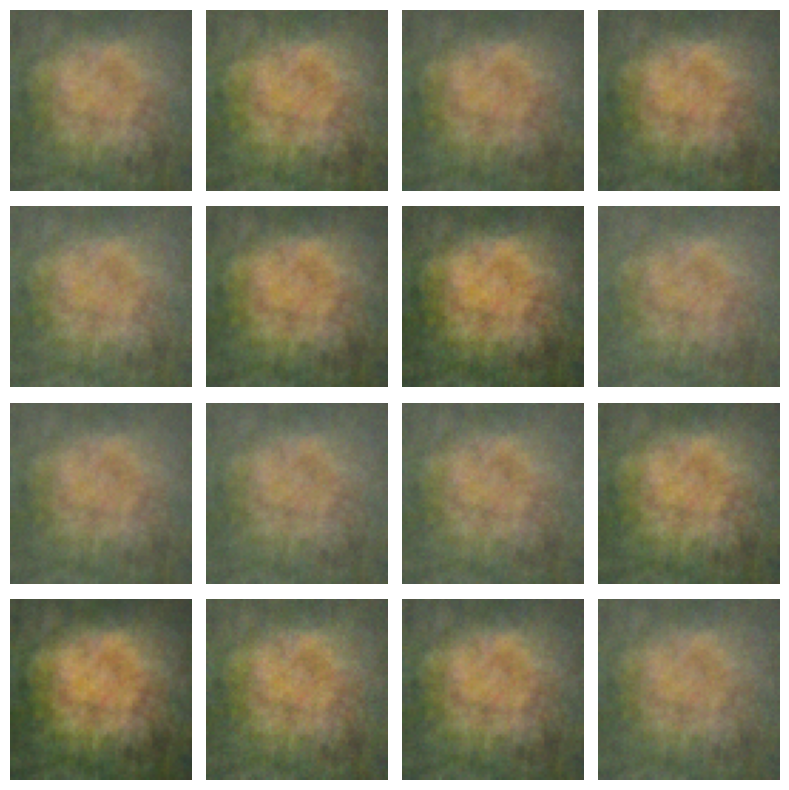

In [14]:
import matplotlib.pyplot as plt

generator.eval()

with torch.no_grad():

    noise = torch.randn(16, 100).to(device)

    text_features = attended_features.repeat(16, 1, 1)

    fake_images = generator(noise, text_features)

fake_images = fake_images.cpu()

fig, axes = plt.subplots(4,4, figsize=(8,8))

for i, ax in enumerate(axes.flatten()):

    img = fake_images[i].permute(1,2,0)

    img = (img + 1) / 2

    img = img.clamp(0,1)

    ax.imshow(img)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [15]:
import os
from torchvision.utils import save_image

os.makedirs("generated_attention_flowers", exist_ok=True)

for i in range(16):

    save_image(
        (fake_images[i] + 1) / 2,
        f"generated_attention_flowers/flower_{i+1}.png"
    )

print("✅ Images Saved Successfully")

✅ Images Saved Successfully


In [16]:
torch.save(generator.state_dict(),
           "attention_generator.pth")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


# Conclusion

In this task, a Cross-Attention mechanism was successfully implemented to improve the interaction between textual descriptions and image features.

The Cross-Attention module uses Multi-Head Attention to combine text embeddings extracted from CLIP with image feature representations before image generation.

The Attention-Enhanced Generator produces images conditioned on the attended text features, improving semantic consistency between the textual input and generated flower images.

The generated outputs demonstrate the successful implementation of an attention strategy for text-to-image generation.